# **EDA - Procesamiento del Lenguaje Natural: Jarvis Calling Hiring Contest**

## 🔹Configuración

In [1]:
# [Config] Librerías

# Principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string, re, warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from collections import Counter
from tqdm import tqdm

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 🔹Data

> Se tienen 2,484 registros de hojas de vida, resumidos en 24 categorías únicas.

In [2]:
df = pd.read_csv(r'../Data/Resume.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [3]:
print("Registros:", df.shape[0])
print("Categorías únicas:", df['Category'].nunique())
cat_table = pd.DataFrame({
    'Frecuency': df['Category'].value_counts(),
    'Porcentaje': round(df['Category'].value_counts(normalize=True)*100, 2)
})
print(cat_table)

Registros: 2484
Categorías únicas: 24
                        Frecuency  Porcentaje
Category                                     
INFORMATION-TECHNOLOGY        120        4.83
BUSINESS-DEVELOPMENT          120        4.83
ADVOCATE                      118        4.75
CHEF                          118        4.75
ENGINEERING                   118        4.75
ACCOUNTANT                    118        4.75
FINANCE                       118        4.75
FITNESS                       117        4.71
AVIATION                      117        4.71
SALES                         116        4.67
BANKING                       115        4.63
HEALTHCARE                    115        4.63
CONSULTANT                    115        4.63
CONSTRUCTION                  112        4.51
PUBLIC-RELATIONS              111        4.47
HR                            110        4.43
DESIGNER                      107        4.31
ARTS                          103        4.15
TEACHER                       102        4

>Las categorías de las hojas de vida dentro del DataSet tienen frecuencias variables, muy altas o muy bajas, que presentar un claro desbalance. Para efectos del análisis hemos de agrupar los registros en macro categorías un poco más balanceadas.

In [4]:
# Macro categorías
def map_macrogrupo(label):
    # Areas económico-empresariales
    if label in ['BUSINESS-DEVELOPMENT', 'ACCOUNTANT', 'FINANCE', 'BANKING', 'CONSULTANT']:
        return 'Negocios y Finanzas'
    # Innovación, técnica y sistemas
    elif label in ['INFORMATION-TECHNOLOGY', 'ENGINEERING', 'DIGITAL-MEDIA', 'AVIATION']:
        return 'Tecnología y Ciencia'
    # Profesiones orientadas a servicios
    elif label in ['ADVOCATE', 'PUBLIC-RELATIONS', 'HR', 'TEACHER', 'HEALTHCARE']:
        return 'Servicios Profesionales y Públicos'
    # Diseño, arte, moda y construcción
    elif label in ['DESIGNER', 'ARTS', 'APPAREL', 'CONSTRUCTION']:
        return 'Creatividad y Producción'
    # Áreas diversas, operativas o nicho
    elif label in ['FITNESS', 'CHEF', 'AGRICULTURE', 'AUTOMOBILE', 'BPO', 'SALES']:
        return 'Otros y Especializados'
    else:
        return 'Sin categoría'

In [5]:
df['macro_label'] = df['Category'].apply(map_macrogrupo)

print("Categorías únicas:", df['macro_label'].nunique())
cat_table = pd.DataFrame({
    'Frecuency': df['macro_label'].value_counts(),
    'Porcentaje': round(df['macro_label'].value_counts(normalize=True)*100, 2)
})
print(cat_table)

Categorías únicas: 5
                                    Frecuency  Porcentaje
macro_label                                              
Negocios y Finanzas                       586       23.59
Servicios Profesionales y Públicos        556       22.38
Otros y Especializados                    472       19.00
Tecnología y Ciencia                      451       18.16
Creatividad y Producción                  419       16.87


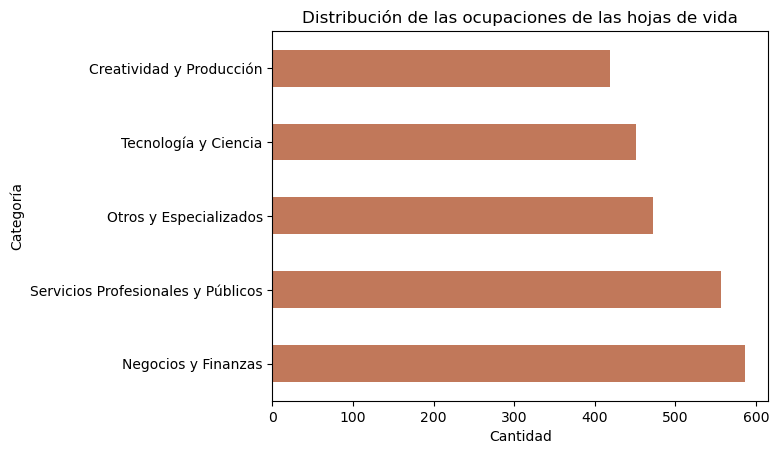

In [6]:
df['macro_label'].value_counts().plot(kind='barh', color='#C1785A')
plt.title('Distribución de las ocupaciones de las hojas de vida')
plt.xlabel('Cantidad')
plt.ylabel('Categoría')
plt.show()

## 🔹Sobre el texto

In [7]:
# Cantidad total de caracteres
df['char_len'] = df['Resume_str'].str.len()
# Cantidad de palabras en un texto separando por espacios
df['word_len'] = df['Resume_str'].apply(lambda x: len(x.split()))
# Cantidad de oraciones en el texto
df['sent_len'] = df['Resume_str'].apply(lambda x: len(sent_tokenize(x)))

# Eliminar textos vacíos
df = df[df['word_len'] > 0].reset_index(drop=True)

In [8]:
print(df[['char_len','word_len','sent_len']].describe())

           char_len     word_len     sent_len
count   2483.000000  2483.000000  2483.000000
mean    6297.835683   811.652437    36.343536
std     2766.943443   370.723976    23.735855
min      881.000000   113.000000     1.000000
25%     5162.500000   651.000000    21.000000
50%     5887.000000   757.000000    34.000000
75%     7227.500000   933.000000    47.000000
max    38842.000000  5190.000000   397.000000


Los resultados revelan la distribución de la extensión de los textos en las hojas de vida.  En promedio, cada texto contiene aproximadamente 6,300 caracteres, 812 palabras y 36 oraciones, lo que sugiere que se trata de documentos relativamente extensos.  

El rango es considerable: algunos textos tienen apenas 113 palabras y una sola oración, mientras que otros alcanzan hasta 5,190 palabras y 397 oraciones. El hecho de que el percentil 75 esté por encima de 7,200 caracteres y 933 palabras sugiere que al menos una cuarta parte de los textos son bastante densos.

En cuanto a la longitud promedio de palabra, el valor medio es de 6.3 caracteres, con una desviación estándar baja (0.37). El mínimo de 4.56 y el máximo de 7.55 muestran que algunos textos usan vocabulario más simple, mientras que otros emplean términos más complejos.

## 🔹 Limpieza de texto

In [9]:
#  [Func] Limpieza de texto
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def text_cleaner(text):
    text = text.lower()
    text = re.sub(r"\n|\t", " ", text)  # elimina saltos de línea y tabulaciones
    text = re.sub(r"http\S+|www\S+|@\S+|#\S+|\d+", " ", text)  # elimina URLs, menciones, hashtags, números
    text = re.sub(r"[_]{2,}", " ", text)  # elimina bloques como __________
    text = re.sub(r"\*", " ", text)  # elimina asteriscos
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)  # elimina puntuación restante
    text = re.sub(r"\s+", " ", text)  # colapsa múltiples espacios
    
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df['clean_text'] = df['Resume_str'].astype(str).apply(text_cleaner)

In [10]:
# Registros vacíos
empty_check = df[df['clean_text'].str.strip() == ""]
print(f"Registros con texto vacío: {len(empty_check)}")

df = df[df['clean_text'].str.strip() != ""]
print(f"Registros restantes: {len(df)}")


Registros con texto vacío: 0
Registros restantes: 2483


## 🔹Análisis longitudinal

In [11]:
df['word_len'] = df['clean_text'].apply(lambda x: len(x.split()))
df['char_len'] = df['clean_text'].apply(len)
df['char_by_len'] = df['char_len'] / df['word_len']
print(df[['word_len', 'char_len', 'char_by_len']].describe())

          word_len      char_len  char_by_len
count  2483.000000   2483.000000  2483.000000
mean    583.997181   4793.141764     8.191531
std     260.107812   2139.580719     0.319474
min      74.000000    529.000000     6.822542
25%     476.000000   3900.000000     8.002993
50%     546.000000   4484.000000     8.216216
75%     673.000000   5539.000000     8.411181
max    3543.000000  27396.000000     9.097808


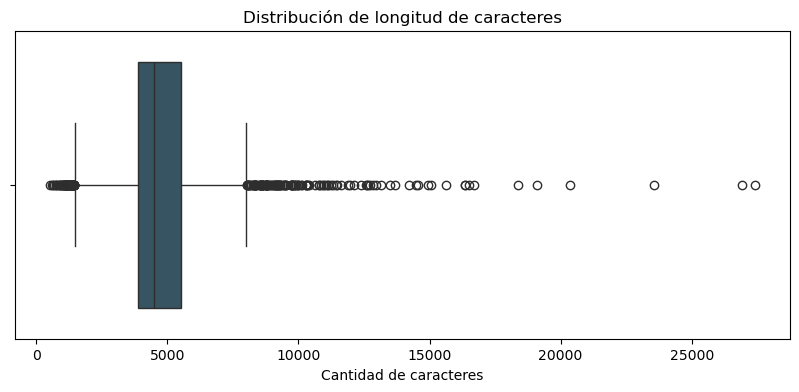

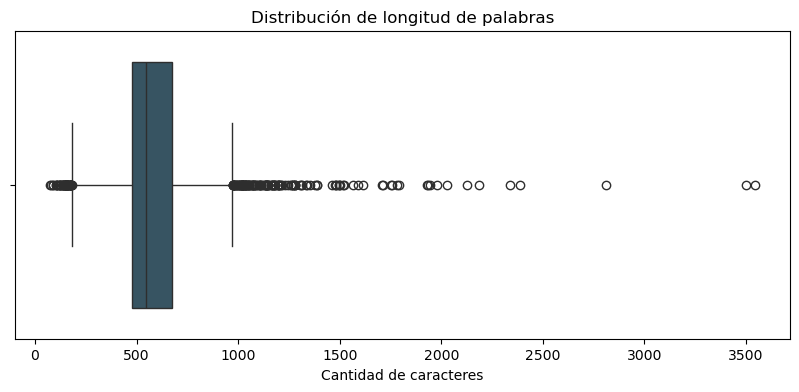

In [12]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['char_len'], color='#305669', orient='h')
plt.title("Distribución de longitud de caracteres")
plt.xlabel("Cantidad de caracteres")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['word_len'], color='#305669', orient='h')
plt.title("Distribución de longitud de palabras")
plt.xlabel("Cantidad de caracteres")
plt.show()

In [13]:
df.groupby('macro_label')['word_len'].mean()

macro_label
Creatividad y Producción              562.947494
Negocios y Finanzas                   589.776068
Otros y Especializados                547.345339
Servicios Profesionales y Públicos    605.834532
Tecnología y Ciencia                  607.494457
Name: word_len, dtype: float64

## 🔹Análisis de frecuencia de palabras

In [14]:
tokens = " ".join(df['clean_text']).split()
word_freq = Counter(tokens)
most_common = word_freq.most_common(10)

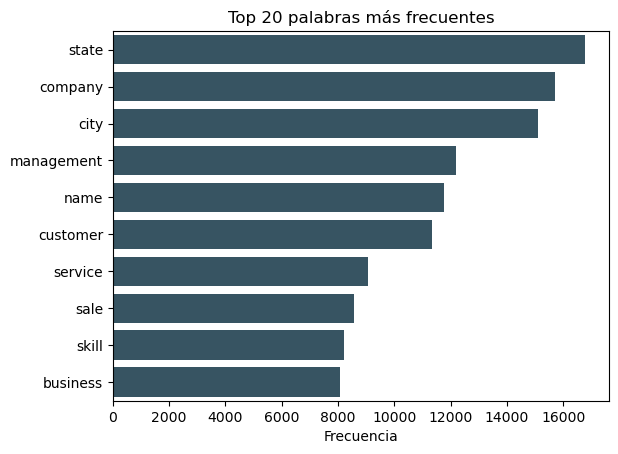

In [15]:
sns.barplot(y=[w for w,_ in most_common], x=[f for _,f in most_common], color='#305669')
plt.title('Top 20 palabras más frecuentes')
plt.xlabel('Frecuencia')
plt.show()

## 🔹 Análisis de n-gramas

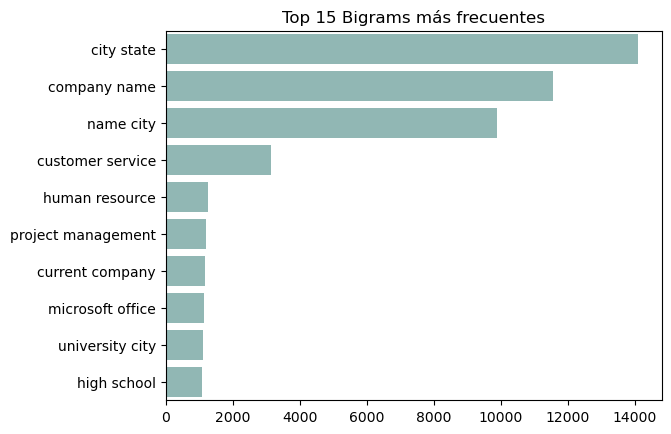

In [16]:
cv_bigram = CountVectorizer(ngram_range=(2,2), max_features=10)
bigrams = cv_bigram.fit_transform(df['clean_text'])
bigram_freq = sorted([(sum(bigrams.toarray()[:, i]), k) for k, i in cv_bigram.vocabulary_.items()], reverse=True)

sns.barplot(x=[f for f,_ in bigram_freq], y=[n for _,n in bigram_freq], color='#8ABEB9')
plt.title('Top 15 Bigrams más frecuentes')
plt.show()

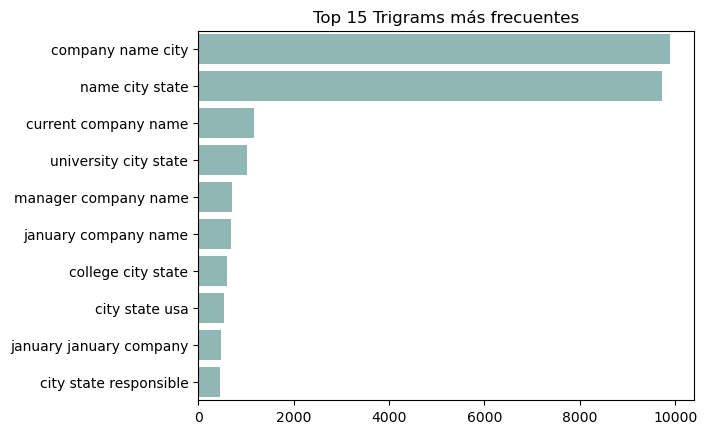

In [17]:
cv_tigram = CountVectorizer(ngram_range=(3,3), max_features=10)
trigrams = cv_tigram.fit_transform(df['clean_text'])
trigram_freq = sorted([(sum(trigrams.toarray()[:, i]), k) for k, i in cv_tigram.vocabulary_.items()], reverse=True)

sns.barplot(x=[f for f,_ in trigram_freq], y=[n for _,n in trigram_freq], color='#8ABEB9')
plt.title('Top 15 Trigrams más frecuentes')
plt.show()

## 🔹Nubes de palabras

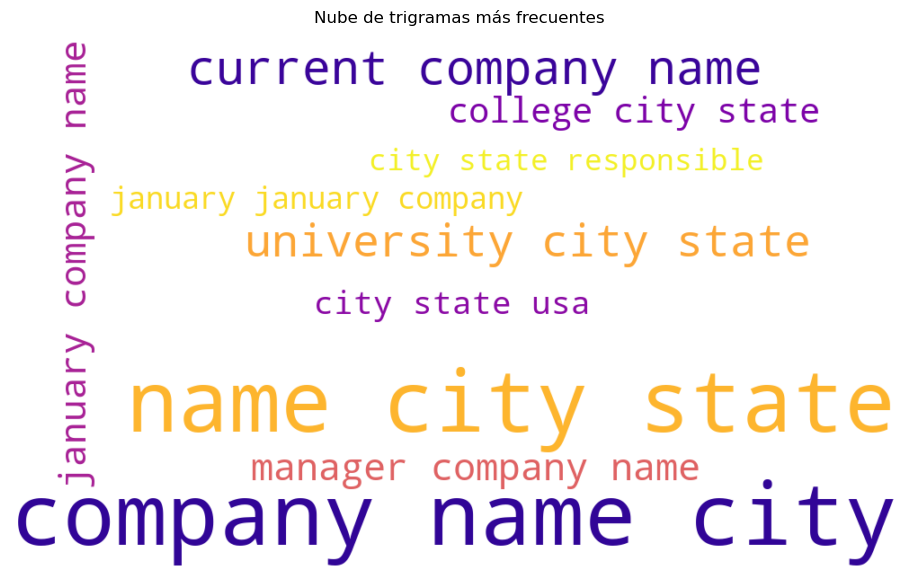

In [18]:
# Crear la nube de palabras

trigram_freq = {
    trigram: trigrams.toarray()[:, i].sum()
    for trigram, i in cv_tigram.vocabulary_.items()
}

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    colormap='plasma',
    max_words=100
).generate_from_frequencies(trigram_freq)

# 4. Mostrar la nube
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de trigramas más frecuentes')
plt.show()


## 🔹Dataset preprocesado

In [19]:
df['tokens'] = df['clean_text'].apply(lambda x: x.split())
df['bert_text'] = df['Resume_str'].astype(str).str.lower().str.replace(r'[^a-zA-Z\s]', '', regex=True)
df['fasttext_text'] = '__label__' + df['Category'].astype(str) + ' ' + df['clean_text']

final_df = df[['macro_label', 'Resume_str', 'clean_text', 'tokens', 'bert_text', 'fasttext_text']]
final_df.to_csv('../Data/Clean_words.csv', index=False)


In [21]:
final_df.head()

,macro_label,Resume_str,clean_text,tokens,bert_text,fasttext_text
0,Servicios Profesionales y Públicos,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,administrator marketing associate administrato...,"[administrator, marketing, associate, administ...",hr administratormarketing associate\n...,__label__HR administrator marketing associate ...
1,Servicios Profesionales y Públicos,"HR SPECIALIST, US HR OPERATIONS ...",specialist operation summary versatile medium ...,"[specialist, operation, summary, versatile, me...",hr specialist us hr operations ...,__label__HR specialist operation summary versa...
2,Servicios Profesionales y Públicos,HR DIRECTOR Summary Over 2...,director summary year experience recruiting pl...,"[director, summary, year, experience, recruiti...",hr director summary over ...,__label__HR director summary year experience r...
3,Servicios Profesionales y Públicos,HR SPECIALIST Summary Dedica...,specialist summary dedicated driven dynamic ye...,"[specialist, summary, dedicated, driven, dynam...",hr specialist summary dedica...,__label__HR specialist summary dedicated drive...
4,Servicios Profesionales y Públicos,HR MANAGER Skill Highlights ...,manager skill highlight skill department start...,"[manager, skill, highlight, skill, department,...",hr manager skill highlights ...,__label__HR manager skill highlight skill depa...
